# זיהוי משטרי שוק באמצעות מודל מרקוב חבוי גאוסי

## מחקר אמפירי רב־נכסי בפרוטוקול כרונולוגי נעול

המחקר בוחן אם **Gaussian Hidden Markov Model (HMM)** מסוגל לתאר משטרים לטנטיים בנתוני שוק ולהפיק מהם תחזית לוגריתמית ליום הבא. היקום הנבדק כולל מניות אמריקאיות, זהב, אג״ח ארוכות ו-Bitcoin: `SPY`, `GLD`, `TLT`, `BTC-USD`, `DIS`.

המחברת היא שכבת ההגשה והפרשנות של הריצה הקנונית `canonical_20260810_014841`. כברירת מחדל היא **אינה מורידה נתונים ואינה מאמנת מודלים**; היא טוענת תוצרים חיצוניים, מאמתת את שלמותם ומציגה את הממצאים. הבחנה זו שומרת על שחזור מהיר של הדוח בלי לערבב בין חישוב מחדש לבין ניתוח תוצאות נעולות.

## 1. סביבת הרצה ותצורה

הנתיבים מוגדרים יחסית לשורש הפרויקט. התא הראשון בודק במפורש שהמחברת מורצת משם, מגדיר סגנון תצוגה וקובע כי ניסויים מלאים אינם מופעלים. כך ברירת המחדל נותרת מקומית, דטרמיניסטית וללא תלות ברשת.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
CANONICAL_RUN_ID = "canonical_20260810_014841"
ARTIFACT_DIR = PROJECT_ROOT / "experiments_canonical" / CANONICAL_RUN_ID
RUN_FULL_EXPERIMENTS = False
ASSET_ORDER = ["SPY", "GLD", "TLT", "BTC-USD", "DIS"]

assert (PROJECT_ROOT / "run_canonical.py").is_file(), (
    "יש להריץ את המחברת משורש הפרויקט; run_canonical.py לא נמצא בתיקייה הנוכחית."
)
assert ARTIFACT_DIR.is_dir(), f"תיקיית התוצרים הקנוניים חסרה: {ARTIFACT_DIR}"

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.style.use("seaborn-v0_8-whitegrid")
print(f"שורש הפרויקט: {PROJECT_ROOT}")
print(f"מקור התוצאות: {ARTIFACT_DIR.relative_to(PROJECT_ROOT)}")
print(f"RUN_FULL_EXPERIMENTS = {RUN_FULL_EXPERIMENTS}")

שורש הפרויקט: /root/projects/advanced-ml-hmm-market-regimes
מקור התוצאות: experiments_canonical/canonical_20260810_014841
RUN_FULL_EXPERIMENTS = False


### הרצה קנונית מלאה — אופציונלית בלבד

הרצה מלאה מורידה את סדרות המחירים מ-Yahoo Finance ומבצעת מחדש את כל התאמות ה-HMM; לכן היא דורשת רשת וסביבה מלאה. הפקודה הקנונית היא:

```bash
/root/hmm_env/bin/python run_canonical.py
```

כדי להפעילה מתוך המחברת יש לשנות ידנית את `RUN_FULL_EXPERIMENTS` ל-`True`. הריצה תיצור תיקיית זמן חדשה ולא תדרוס את התוצרים שעליהם מבוסס הניתוח הנוכחי.

In [2]:
if RUN_FULL_EXPERIMENTS:
    completed = subprocess.run(
        [sys.executable, "run_canonical.py"],
        cwd=PROJECT_ROOT,
        check=True,
        text=True,
    )
    print(f"הריצה הקנונית הסתיימה עם קוד יציאה {completed.returncode}.")
else:
    print("הרצה מלאה לא הופעלה; הניתוח משתמש בתוצרים הקנוניים החיצוניים.")

הרצה מלאה לא הופעלה; הניתוח משתמש בתוצרים הקנוניים החיצוניים.


## 2. טעינת התוצרים ובדיקות תקינות

שלושת מקורות המידע המרכזיים הם: מניפסט התצורה, טבלת תוצאות המבחן ואבחוני כל התחלות ה-HMM. בנוסף נדרשים לכל נכס סיכום מצבים, מטריצת מעבר, אבחון מעבר ואיורים. אין בתאים הבאים עותק קשיח של התוצאות; כל המספרים נקראים מקבצי הריצה.

In [3]:
with (ARTIFACT_DIR / "manifest.json").open(encoding="utf-8") as f:
    manifest = json.load(f)
with (ARTIFACT_DIR / "model_diagnostics.json").open(encoding="utf-8") as f:
    diagnostics = json.load(f)
results = pd.read_csv(ARTIFACT_DIR / "results.csv")

selected = {asset: diagnostics[asset]["selected"] for asset in ASSET_ORDER}
required_asset_files = []
for asset in ASSET_ORDER:
    k = int(selected[asset]["k"])
    required_asset_files.extend([
        ARTIFACT_DIR / asset / "test_results.csv",
        ARTIFACT_DIR / asset / f"state_table_K{k}.csv",
        ARTIFACT_DIR / asset / f"transition_matrix_K{k}.csv",
        ARTIFACT_DIR / asset / f"transition_analysis_K{k}.json",
        ARTIFACT_DIR / asset / f"{asset}_price_states_K{k}.png",
        ARTIFACT_DIR / asset / f"{asset}_returns_states_K{k}.png",
        ARTIFACT_DIR / asset / f"{asset}_transition_matrix_K{k}.png",
        ARTIFACT_DIR / asset / f"{asset}_state_characteristics_K{k}.png",
    ])

assert manifest["run_id"] == CANONICAL_RUN_ID
assert manifest["protocol_version"] == "1.0"
assert manifest["assets"] == ASSET_ORDER
assert all(row["status"] == "completed" for row in manifest["folds_completed"])
assert len(results) == len(ASSET_ORDER) * 5
assert set(results["asset"]) == set(ASSET_ORDER)
assert results.groupby("asset").size().eq(5).all()
assert not [p for p in required_asset_files if not p.is_file()]

print(f"נטענו {len(results)} תוצאות מבחן עבור {len(ASSET_ORDER)} נכסים.")
print(f"אומתו {len(required_asset_files)} תוצרים ברמת הנכס.")

נטענו 25 תוצאות מבחן עבור 5 נכסים.
אומתו 40 תוצרים ברמת הנכס.


### טענות פרוטוקול הניתנות לבדיקה

הפרוטוקול נועד למנוע **דליפת עתיד** ולשמור את קבוצת המבחן להערכה אחת לאחר בחירת המודל:

1. החלוקה היא כרונולוגית: 70% אימון, 15% אימות ו-15% מבחן.
2. שורות גבול מוסרות כאשר יעד היום הבא היה חוצה מחיצה.
3. התקנון (`StandardScaler`) מותאם לנתוני האימון בלבד ומוחל ללא התאמה על אימות ומבחן.
4. מספר המצבים $K\in\{2,3,4\}$ והאתחול נבחרים לפי log-likelihood באימות בלבד.
5. פענוח המצבים מחוץ למדגם הוא prefix-based: בנקודת זמן $t$ נעשה שימוש רק בתצפיות עד $t$.
6. כל המודלים הבסיסיים וה-HMM הנבחר נמדדים על אותה מחיצת מבחן.

התא הבא בודק הן את תצורת המניפסט והן את מימוש נקודות המפתח בקוד הקנוני. הבדיקה אינה מחליפה ביקורת קוד, אך היא מונעת ניתוק בין ההצהרה המתודולוגית לבין הריצה שהופקה.

In [4]:
config = manifest["config"]
runner_source = (PROJECT_ROOT / "run_canonical.py").read_text(encoding="utf-8")
data_source = (PROJECT_ROOT / "src" / "data.py").read_text(encoding="utf-8")
model_source = (PROJECT_ROOT / "src" / "model.py").read_text(encoding="utf-8")

protocol_checks = {
    "יחסי החלוקה הם 70/15/15": np.isclose(1-config["validation_size"]-config["test_size"], 0.70),
    "מרחב K נעול ל-2,3,4": config["k_values"] == [2, 3, 4],
    "שלושה אתחולים קבועים": config["seeds"] == [42, 123, 456],
    "ארבעה משתני הסבר קבועים": len(config["feature_cols"]) == 4,
    "חלוקה בטוחה ליעד נקראת ברץ": "target_safe_train_validation_test_split(" in runner_source,
    "התקנון מותאם לאימון בלבד": "scaler.fit_transform(splits.train" in runner_source,
    "בחירה לפי LL באימות": "max(converged_starts, key=lambda r: r.log_likelihood_val)" in runner_source,
    "מטריקת מבחן אינה במפתח הבחירה": "key=lambda r: r.log_likelihood_test" not in runner_source,
    "שורות גבול מוסרות בקוד החלוקה": "train_end - 1" in data_source and "validation_end - 1" in data_source,
    "פענוח מחוץ למדגם משתמש בקידומות": "X_test_scaled[:i+1]" in model_source,
}
check_table = pd.DataFrame({"בדיקת פרוטוקול": protocol_checks.keys(), "עבר": protocol_checks.values()})
assert check_table["עבר"].all(), check_table.loc[~check_table["עבר"]]
display(check_table)

config_table = pd.DataFrame({
    "רכיב": ["טווח נתונים", "יחסי אימון/אימות/מבחן", "תכונות", "K מועמדים", "אתחולים", "קו-וריאנציה", "חלון הקשר"],
    "ערך": [
        f'{config["start_date"]} — {config["end_date"]}',
        "70% / 15% / 15%",
        ", ".join(config["feature_cols"]),
        str(config["k_values"]),
        str(config["seeds"]),
        config["covariance_type"],
        str(config["context_window"]),
    ],
})
display(config_table)

,בדיקת פרוטוקול,עבר
0,יחסי החלוקה הם 70/15/15,True
1,"מרחב K נעול ל-2,3,4",True
2,שלושה אתחולים קבועים,True
3,ארבעה משתני הסבר קבועים,True
4,חלוקה בטוחה ליעד נקראת ברץ,True
5,התקנון מותאם לאימון בלבד,True
6,בחירה לפי LL באימות,True
7,מטריקת מבחן אינה במפתח הבחירה,True
8,שורות גבול מוסרות בקוד החלוקה,True
9,פענוח מחוץ למדגם משתמש בקידומות,True


,רכיב,ערך
0,טווח נתונים,2014-01-01 — 2024-12-31
1,יחסי אימון/אימות/מבחן,70% / 15% / 15%
2,תכונות,"log_return, rolling_volatility_20, daily_range..."
3,K מועמדים,"[2, 3, 4]"
4,אתחולים,"[42, 123, 456]"
5,קו-וריאנציה,full
6,חלון הקשר,100


## 3. ניסוח המודל והתחזית

לכל יום $t$ נצפה וקטור תכונות

$$x_t=(r_t,\ \sigma_{20,t},\ \mathrm{range}_t,\ \Delta\log V_t),$$

כאשר $r_t=\log(P_t/P_{t-1})$. המצב $z_t\in\{1,\dots,K\}$ אינו נצפה ישירות ומקיים תכונת מרקוב מסדר ראשון:

$$P(z_t\mid z_{1:t-1})=P(z_t\mid z_{t-1}), \qquad x_t\mid z_t=k\sim\mathcal N(\mu_k,\Sigma_k).$$

פרמטרי המודל נאמדים באלגוריתם Baum–Welch, שהוא מקרה של EM. לאחר פענוח מצב נוכחי $s$, תחזית התשואה ליום הבא היא תוחלת מותנית דרך מטריצת המעבר:

$$\widehat r_{t+1}=\sum_{j=1}^{K}A_{sj}\,\bar r_j,$$

כאשר $A_{sj}=P(z_{t+1}=j\mid z_t=s)$ ו-$\bar r_j$ היא התשואה הממוצעת במצב $j$ **במדגם האימון בלבד**. המודל אינו אסטרטגיית מסחר: ההערכה עוסקת באיכות חיזוי ובמבנה סטטיסטי, ללא עלויות עסקה, מגבלות נזילות או אופטימיזציית תיק.

מדדי ההערכה הם DPA לכיוון התשואה, MAE ו-RMSE לתשואה, MAPE למחיר היום הבא ו-log-likelihood עבור ה-HMM. DPA מוגדר כך שאפס מסווג ככיוון לא-שלילי, באופן עקבי לכל המודלים.

## 4. תוצאות מבחן נעול והשוואה למודלים בסיסיים

ארבעת קווי הבסיס מייצגים רמות מורכבות עולות: ממוצע אימון, התמדה, ממוצע נע לחמישה ימים ושרשרת מרקוב בדידה לכיוון. השוואה זו חשובה משום שמודל לטנטי מורכב ראוי להערכה מול כללים פשוטים על אותו חלון מבחן, ולא רק לפי התאמה בתוך המדגם.

In [5]:
result_view = results[[
    "asset", "model_name", "model_family", "dpa", "mae_return",
    "rmse_return", "mape_price_pct", "runtime_sec"
]].copy()
result_view.columns = ["נכס", "מודל", "משפחה", "DPA", "MAE תשואה", "RMSE תשואה", "MAPE מחיר (%)", "זמן (שניות)"]
for c in ["DPA", "MAE תשואה", "RMSE תשואה", "MAPE מחיר (%)", "זמן (שניות)"]:
    result_view[c] = result_view[c].astype(float).round(6)
display(result_view)

,נכס,מודל,משפחה,DPA,MAE תשואה,RMSE תשואה,MAPE מחיר (%),זמן (שניות)
0,SPY,Naive - train mean,baseline,0.584951,0.005763,0.007656,0.576339,0.000009
1,SPY,Naive - persistence,baseline,0.531553,0.008163,0.010429,0.816057,0.000033
2,SPY,Moving Average 5,baseline,0.531553,0.006510,0.008461,0.650944,0.001550
3,SPY,Discrete Markov Chain,baseline,0.584951,0.005779,0.007678,0.578008,0.000206
4,SPY,Gaussian HMM K=4 (selected),hmm,0.584951,0.005754,0.007657,0.575569,0.305287
5,GLD,Naive - train mean,baseline,0.533981,0.006635,0.008755,0.663415,0.000010
6,GLD,Naive - persistence,baseline,0.504854,0.009622,0.012583,0.962305,0.000035
7,GLD,Moving Average 5,baseline,0.516990,0.007252,0.009513,0.725663,0.001519
8,GLD,Discrete Markov Chain,baseline,0.533981,0.006635,0.008755,0.663441,0.000204
9,GLD,Gaussian HMM K=4 (selected),hmm,0.533981,0.006637,0.008751,0.663612,0.445892


,נכס,K נבחר,Seed,DPA HMM,DPA בסיס מיטבי,הפרש DPA,MAE HMM,MAE בסיס מיטבי,הפרש MAE
0,SPY,4,456,0.584951,0.584951,0.000000,0.005754,0.005763,-0.000008
1,GLD,4,123,0.533981,0.533981,0.000000,0.006637,0.006635,0.000002
2,TLT,3,123,0.502427,0.512136,-0.009709,0.007937,0.007933,0.000004
3,BTC-USD,4,123,0.504456,0.513369,-0.008913,0.017997,0.017847,0.000150
4,DIS,4,123,0.514563,0.514563,0.000000,0.010840,0.010832,0.000008


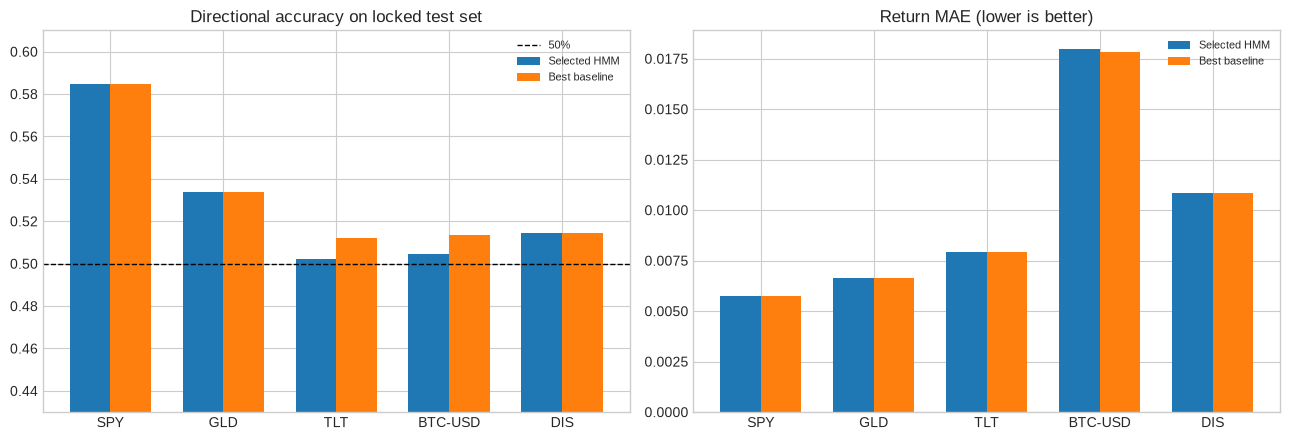

In [6]:
comparison_rows = []
for asset in ASSET_ORDER:
    block = results[results["asset"] == asset]
    hmm = block[block["model_family"] == "hmm"].iloc[0]
    baselines = block[block["model_family"] == "baseline"]
    best_dpa = baselines.loc[baselines["dpa"].idxmax()]
    best_mae = baselines.loc[baselines["mae_return"].idxmin()]
    comparison_rows.append({
        "נכס": asset,
        "K נבחר": int(hmm["k"]),
        "Seed": int(hmm["seed"]),
        "DPA HMM": hmm["dpa"],
        "DPA בסיס מיטבי": best_dpa["dpa"],
        "הפרש DPA": hmm["dpa"] - best_dpa["dpa"],
        "MAE HMM": hmm["mae_return"],
        "MAE בסיס מיטבי": best_mae["mae_return"],
        "הפרש MAE": hmm["mae_return"] - best_mae["mae_return"],
    })
comparison = pd.DataFrame(comparison_rows)
display(comparison.round(6))

x = np.arange(len(comparison))
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(x-0.18, comparison["DPA HMM"], 0.36, label="Selected HMM")
axes[0].bar(x+0.18, comparison["DPA בסיס מיטבי"], 0.36, label="Best baseline")
axes[0].axhline(0.5, color="black", ls="--", lw=1, label="50%")
axes[0].set_xticks(x, comparison["נכס"]); axes[0].set_ylim(0.43, 0.61)
axes[0].set_title("Directional accuracy on locked test set"); axes[0].legend(fontsize=8)
axes[1].bar(x-0.18, comparison["MAE HMM"], 0.36, label="Selected HMM")
axes[1].bar(x+0.18, comparison["MAE בסיס מיטבי"], 0.36, label="Best baseline")
axes[1].set_xticks(x, comparison["נכס"]); axes[1].set_title("Return MAE (lower is better)")
axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

### פירוש ההשוואה

יתרון כיווני מוגדר כאן ביחס **לקו הבסיס הטוב ביותר לכל נכס**, ולכן זהו מבחן מחמיר יותר מהשוואה לקו בסיס יחיד. פער אפס משמעו שוויון ולא שיפור. מאחר שהריצה שומרת מדדים מצרפיים בלבד ולא את וקטורי התחזיות המזווגים לכל מודל, אין להפיק מהם בדיקת McNemar תקפה; טענת מובהקות סטטיסטית הייתה מחייבת את רצף ההצלחות/כישלונות לכל יום.

In [7]:
strict_dpa_wins = int((comparison["הפרש DPA"] > 0).sum())
dpa_ties = int(np.isclose(comparison["הפרש DPA"], 0).sum())
strict_mae_wins = int((comparison["הפרש MAE"] < 0).sum())
print(f"שיפור DPA קפדני מול קו הבסיס הטוב ביותר: {strict_dpa_wins} מתוך {len(comparison)} נכסים.")
print(f"שוויון DPA מול קו הבסיס הטוב ביותר: {dpa_ties} מתוך {len(comparison)} נכסים.")
print(f"MAE נמוך יותר מקו הבסיס הטוב ביותר: {strict_mae_wins} מתוך {len(comparison)} נכסים.")

שיפור DPA קפדני מול קו הבסיס הטוב ביותר: 0 מתוך 5 נכסים.
שוויון DPA מול קו הבסיס הטוב ביותר: 3 מתוך 5 נכסים.
MAE נמוך יותר מקו הבסיס הטוב ביותר: 1 מתוך 5 נכסים.


## 5. אבחוני בחירת $K$ ואתחול

HMM מאומן באמצעות אופטימיזציה לא-קמורה, ולכן אתחולים שונים עשויים להתכנס לפתרונות שונים. לכל נכס נבדקו תשעה שילובים: שלושה ערכי $K$ ושלושה seeds. הבחירה נעשתה לפי log-likelihood באימות מבין התאמות שהתכנסו; ה-log-likelihood של המבחן נשמר לאבחון לאחר הבחירה בלבד.

AIC ו-BIC המוצגים להלן מחושבים על התאמת האימון ומשקפים פשרה בין התאמה למורכבות. הם אינם קריטריון הבחירה הקנוני בריצה זו, ולכן אי-התאמה בינם לבין הבחירה לפי אימות אינה סתירה אלא ביטוי למטרות שונות.

In [8]:
diag_rows = []
for asset in ASSET_ORDER:
    for key, record in diagnostics[asset].items():
        if key == "selected":
            continue
        diag_rows.append({"asset": asset, **record})
diag_df = pd.DataFrame(diag_rows)

for asset in ASSET_ORDER:
    converged = diag_df[(diag_df.asset == asset) & diag_df.converged]
    best = converged.loc[converged["val_log_likelihood"].idxmax()]
    chosen = diagnostics[asset]["selected"]
    assert int(best["k"]) == int(chosen["k"])
    assert int(best["seed"]) == int(chosen["seed"])
    assert chosen["selected_by"] == "val_ll"

k_summary = (diag_df.groupby(["asset", "k"], as_index=False)
             .agg(starts=("seed", "size"), converged=("converged", "sum"),
                  best_val_ll=("val_log_likelihood", "max"),
                  mean_val_dpa=("dpa_val", "mean"),
                  min_aic=("aic", "min"), min_bic=("bic", "min"),
                  max_iterations=("iterations", "max")))
k_summary["selected_K"] = [
    int(row.k) == int(diagnostics[row.asset]["selected"]["k"])
    for row in k_summary.itertuples()
]
display(k_summary.round(3))
print(f"התכנסויות: {int(diag_df.converged.sum())}/{len(diag_df)} התאמות; הבחירות אומתו מחדש לפי LL באימות.")

,asset,k,starts,converged,best_val_ll,mean_val_dpa,min_aic,min_bic,max_iterations,selected_K
0,BTC-USD,2,3,3,-2182.326,0.477,23215.948,23397.876,34,False
1,BTC-USD,3,3,3,-2034.538,0.478,21092.489,21385.921,170,False
2,BTC-USD,4,3,3,-2001.566,0.469,19951.939,20368.612,115,True
3,DIS,2,3,3,-2353.508,0.467,16166.058,16338.437,38,False
4,DIS,3,3,3,-2246.223,0.467,14557.581,14835.611,56,False
5,DIS,4,3,3,-2063.097,0.467,13482.487,13877.290,169,True
6,GLD,2,3,3,-2023.902,0.521,18209.793,18382.172,48,False
7,GLD,3,3,3,-1861.540,0.521,16572.234,16850.264,190,False
8,GLD,4,3,3,-1763.707,0.517,16074.981,16469.784,117,True
9,SPY,2,3,3,-2139.592,0.543,14763.277,14935.655,21,False


התכנסויות: 45/45 התאמות; הבחירות אומתו מחדש לפי LL באימות.


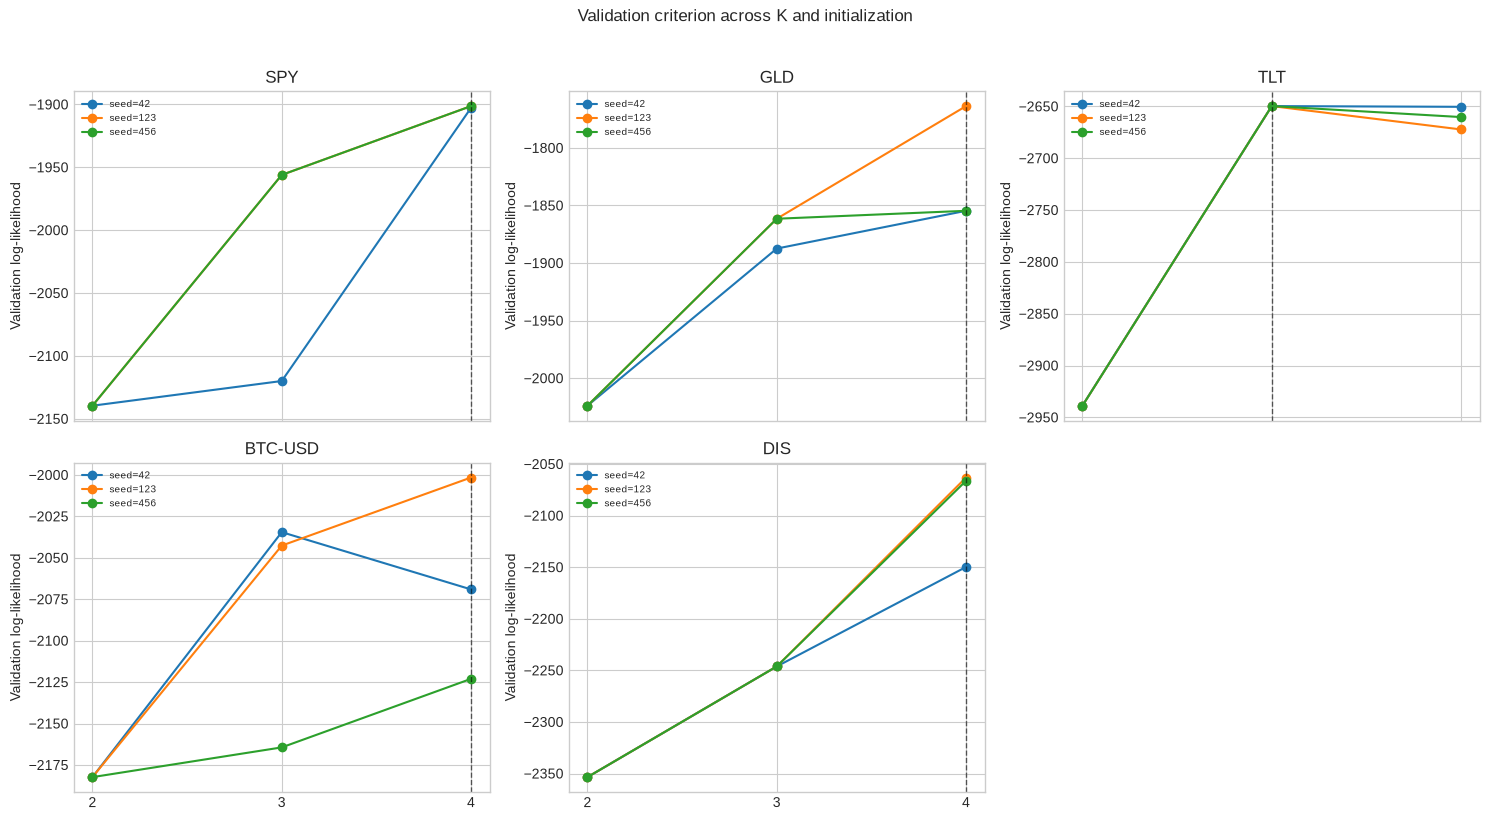

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
for ax, asset in zip(axes.flat, ASSET_ORDER):
    part = diag_df[diag_df.asset == asset]
    for seed, seed_part in part.groupby("seed"):
        seed_part = seed_part.sort_values("k")
        ax.plot(seed_part["k"], seed_part["val_log_likelihood"], marker="o", label=f"seed={int(seed)}")
    chosen_k = int(diagnostics[asset]["selected"]["k"])
    ax.axvline(chosen_k, color="black", ls="--", lw=1, alpha=.6)
    ax.set_title(asset); ax.set_xticks(config["k_values"]); ax.set_ylabel("Validation log-likelihood")
    ax.legend(fontsize=7)
axes.flat[-1].axis("off")
fig.suptitle("Validation criterion across K and initialization", y=1.02)
plt.tight_layout(); plt.show()

## 6. מאפייני המצבים ומבנה המעברים

מספרי המצבים הם תוויות נומינליות בלבד: `State 0` בנכס אחד אינו שקול ל-`State 0` בנכס אחר. המשמעות הכלכלית נגזרת בדיעבד מן התשואה הממוצעת, התנודתיות, השכיחות ומשך הרצף. משום שהסיכומים מחושבים על מדגם האימון, הם מתארים את המבנה שנלמד ואינם משתמשים בתוצאות המבחן לצורך מתן שם למשטר.

האלכסון של מטריצת המעבר מודד התמדה יומית ממוצעת. ערך גבוה מצביע על משטרים יציבים יחסית, אך אינו מוכיח סיבתיות כלכלית. `spectral gap` קטן עשוי להעיד על ערבוב איטי יותר של השרשרת. הטבלאות הבאות מוצגות לכל חמשת הנכסים.

In [10]:
transition_rows = []
state_tables = {}
transition_matrices = {}
for asset in ASSET_ORDER:
    k = int(selected[asset]["k"])
    asset_dir = ARTIFACT_DIR / asset
    states = pd.read_csv(asset_dir / f"state_table_K{k}.csv")
    matrix = pd.read_csv(asset_dir / f"transition_matrix_K{k}.csv", index_col=0)
    with (asset_dir / f"transition_analysis_K{k}.json").open(encoding="utf-8") as f:
        trans_diag = json.load(f)
    assert len(states) == k and matrix.shape == (k, k)
    assert np.allclose(matrix.sum(axis=1), 1.0, atol=1e-6)
    assert np.isclose(np.trace(matrix)/k, trans_diag["average_diagonal_probability"], atol=1e-6)
    state_tables[asset], transition_matrices[asset] = states, matrix
    transition_rows.append({
        "נכס": asset, "K": k,
        "הסתברות אלכסונית ממוצעת": trans_diag["average_diagonal_probability"],
        "אנטרופיית שורה ממוצעת": trans_diag["average_row_entropy"],
        "Spectral gap": trans_diag["spectral_gap"],
        "מצב בעל תשואה ממוצעת נמוכה ביותר": int(states.loc[states["mean_daily_return_%"].idxmin(), "state"]),
        "מצב בעל תנודתיות גבוהה ביותר": int(states.loc[states["volatility_daily_%"].idxmax(), "state"]),
    })

display(pd.DataFrame(transition_rows).round(4))

for asset in ASSET_ORDER:
    display(Markdown(f"### {asset}: סיכום מצבים"))
    view = state_tables[asset].rename(columns={
        "state": "מצב", "frequency_%": "שכיחות (%)",
        "mean_daily_return_%": "תשואה יומית ממוצעת (%)",
        "volatility_daily_%": "תנודתיות יומית (%)",
        "mean_rolling_volatility_%": "תנודתיות נעה ממוצעת (%)",
        "avg_duration_days": "משך ממוצע (ימים)",
    })
    display(view.round(4))
    display(Markdown("**מטריצת מעבר:**"))
    display(transition_matrices[asset].round(4))

,נכס,K,הסתברות אלכסונית ממוצעת,אנטרופיית שורה ממוצעת,Spectral gap,מצב בעל תשואה ממוצעת נמוכה ביותר,מצב בעל תנודתיות גבוהה ביותר
0,SPY,4,0.9416,0.2418,0.0384,3,3
1,GLD,4,0.6770,0.4233,0.0343,0,3
2,TLT,3,0.9123,0.2933,0.0279,0,1
3,BTC-USD,4,0.7226,0.6131,0.0779,1,1
4,DIS,4,0.9128,0.3312,0.0369,1,3


### SPY: סיכום מצבים

,מצב,שכיחות (%),תשואה יומית ממוצעת (%),תנודתיות יומית (%),תנודתיות נעה ממוצעת (%),משך ממוצע (ימים)
0,0,38.1572,0.0611,0.6642,0.6934,26.1786
1,1,28.3186,0.0810,1.1783,1.2647,28.6316
2,2,29.4638,0.0908,0.4161,0.4240,33.2941
3,3,4.0604,-0.4424,3.7098,2.9294,8.6667


**מטריצת מעבר:**

,to_state_0,to_state_1,to_state_2,to_state_3
from_state_0,0.9597,0.0096,0.0235,0.0072
from_state_1,0.0330,0.9596,0.0000,0.0074
from_state_2,0.0224,0.0096,0.9680,0.0000
from_state_3,0.0000,0.1079,0.0130,0.8791


...

,to_state_0,to_state_1,to_state_2,to_state_3
from_state_0,0.9459,0.0366,0.0000,0.0175
from_state_1,0.0304,0.3431,0.1145,0.5120
from_state_2,0.0236,0.0366,0.9232,0.0166
from_state_3,0.0051,0.2665,0.0500,0.6784


### DIS: סיכום מצבים

,מצב,שכיחות (%),תשואה יומית ממוצעת (%),תנודתיות יומית (%),תנודתיות נעה ממוצעת (%),משך ממוצע (ימים)
0,0,40.6559,0.0613,0.8074,0.7857,45.9412
1,1,28.3186,0.0088,1.1356,1.2038,17.0000
2,2,21.1348,0.1093,1.3436,1.8986,14.5000
3,3,9.8907,0.0160,4.0285,3.1027,5.4286


**מטריצת מעבר:**

,to_state_0,to_state_1,to_state_2,to_state_3
from_state_0,0.9765,0.0149,0.0000,0.0086
from_state_1,0.0304,0.9383,0.0012,0.0301
from_state_2,0.0049,0.0356,0.9253,0.0342
from_state_3,0.0000,0.0432,0.1457,0.8112


## 7. המחשה גרפית של המשטרים — כל הנכסים

לכל נכס מוצגים שני איורים נבחרים מן הריצה הקנונית: סדרת המחיר הצבועה לפי המצב המפוענח ומפת החום של מטריצת המעבר. צבעי המצבים אינם מייצגים אותה משמעות בין נכסים; את משמעותם יש לקרוא יחד עם טבלת המאפיינים לעיל. האיורים כוללים את האימון ואת המבחן, כאשר מצבי המבחן פוענחו באופן past-only.

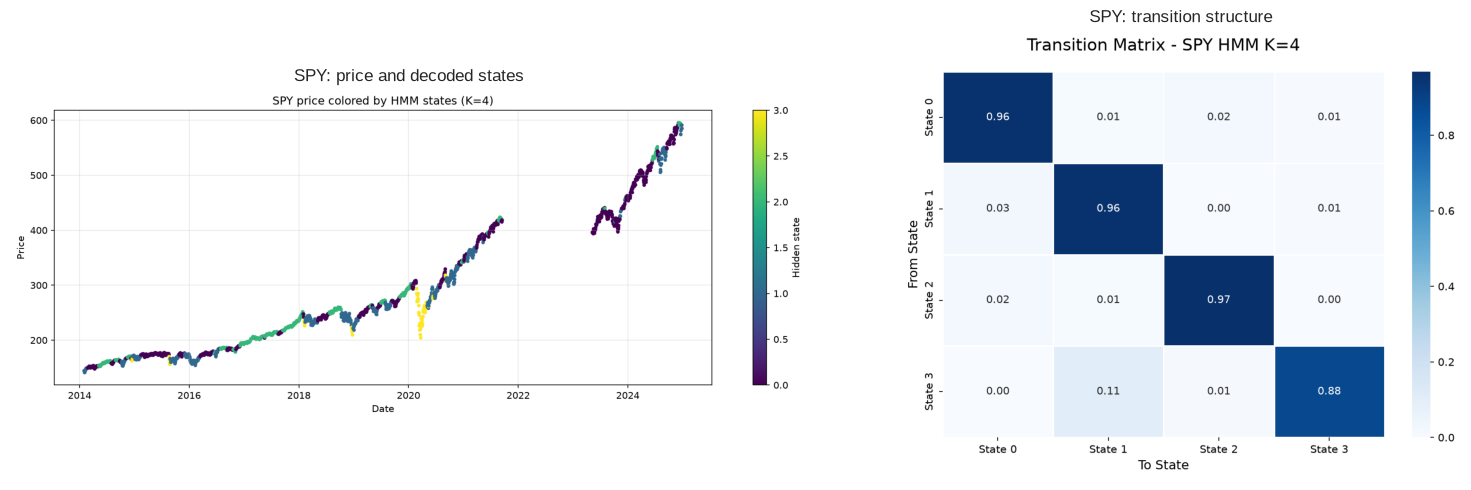

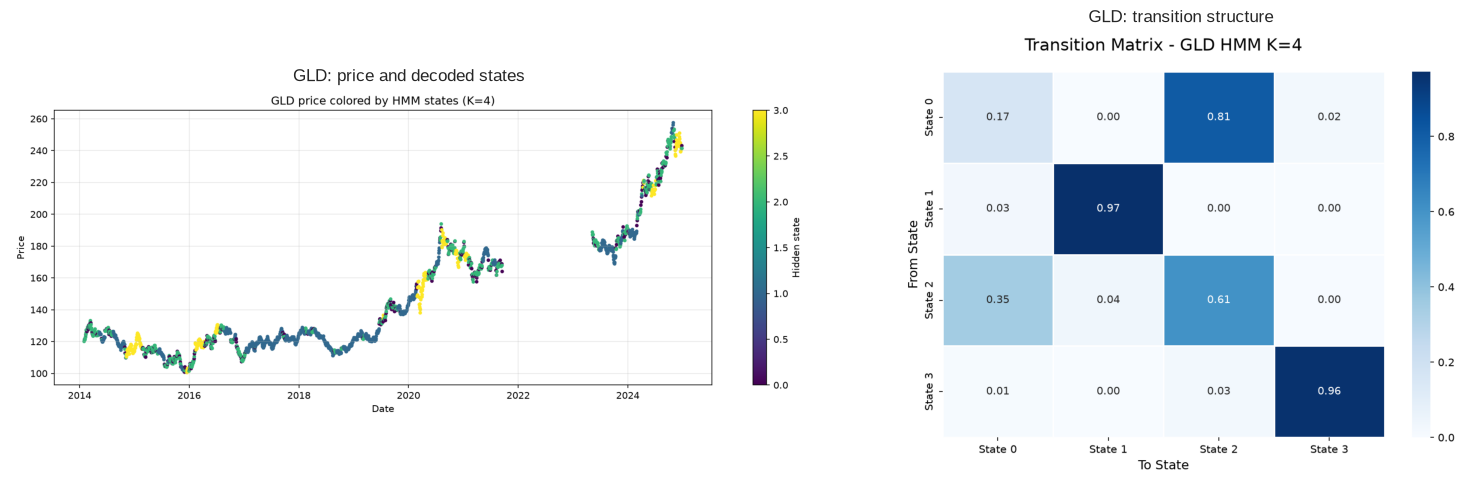

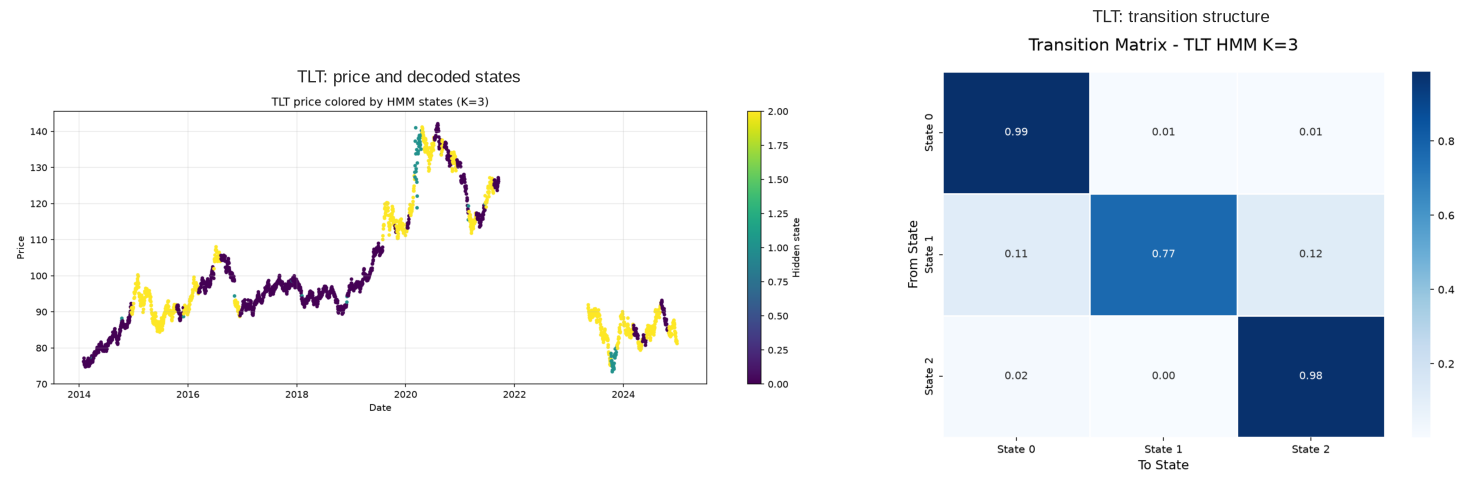

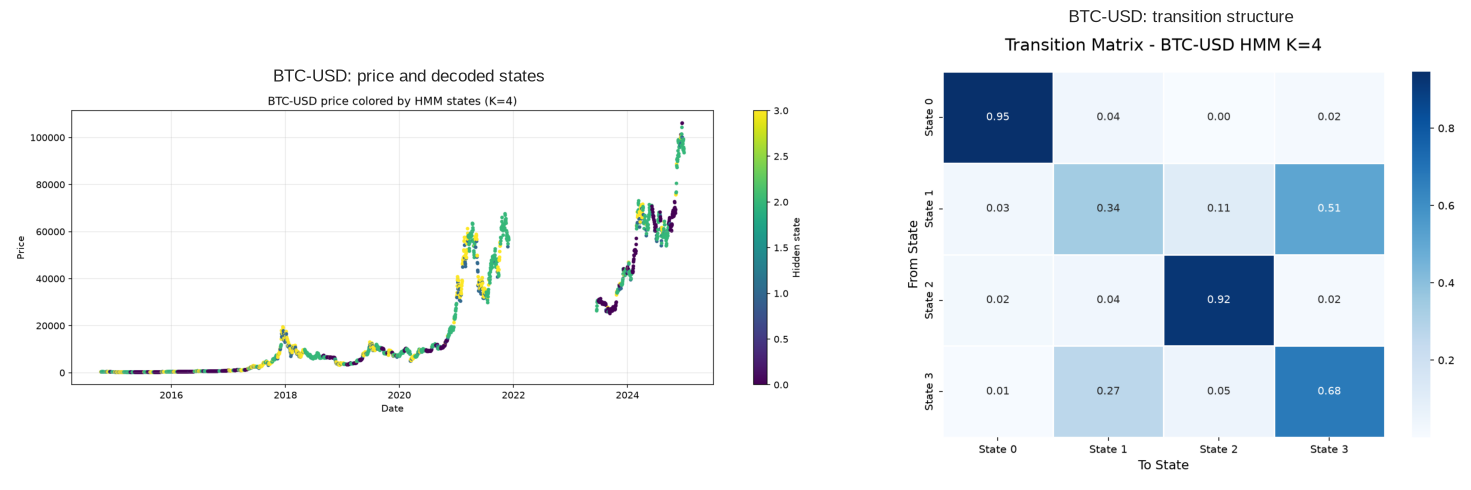

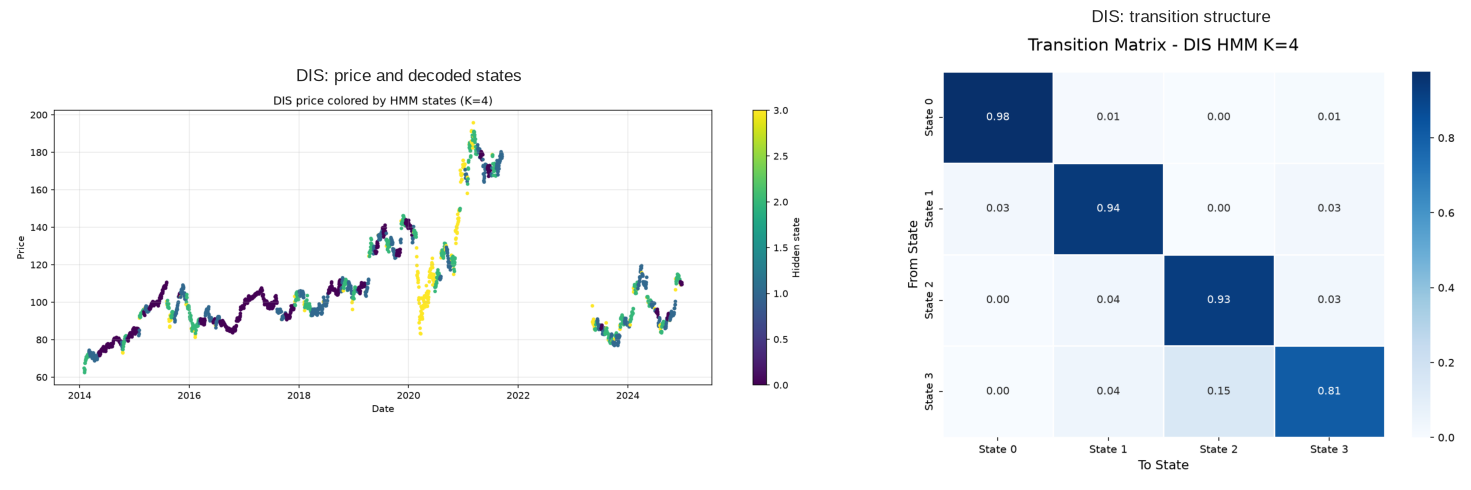

In [11]:
for asset in ASSET_ORDER:
    k = int(selected[asset]["k"])
    asset_dir = ARTIFACT_DIR / asset
    price_img = plt.imread(asset_dir / f"{asset}_price_states_K{k}.png")
    transition_img = plt.imread(asset_dir / f"{asset}_transition_matrix_K{k}.png")
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].imshow(price_img); axes[0].axis("off"); axes[0].set_title(f"{asset}: price and decoded states")
    axes[1].imshow(transition_img); axes[1].axis("off"); axes[1].set_title(f"{asset}: transition structure")
    plt.tight_layout(); plt.show()

## 8. מסקנות, מגבלות ותוקף הממצאים

הממצאים הקנוניים מצביעים על יכולת ברורה של ה-HMM **לתאר הטרוגניות במשטרי תשואה ותנודתיות**: בכל נכס מתקבלים מצבים בעלי שכיחויות, תנודיויות ומשך שונים, ומטריצות המעבר מצביעות על התמדה ניכרת. עם זאת, איכות תיאור המשטרים אינה שקולה בהכרח ליתרון חיזוי.

בהערכה מחוץ למדגם, ה-HMM הנבחר אינו משיג שיפור DPA קפדני על פני קו הבסיס הטוב ביותר באף אחד מחמשת הנכסים; במספר נכסים מתקבל שוויון. גם ב-MAE אין יתרון עקבי. לפיכך, המסקנה הנתמכת היא שהמודל שימושי בעיקר ככלי **תיאורי ופרשני** בריצה זו, ולא הוצגה עדות מספקת לעליונות תחזיתית או לרווחיות.

מגבלות מרכזיות:

- מדובר בחלוקה כרונולוגית יחידה וביקום של חמישה נכסים; אין כאן הערכת walk-forward מרובת תקופות.
- ההתפלגות הגאוסית עלולה להיות מצמצמת עבור זנבות כבדים וא-סימטריה בתשואות.
- בחירת $K$ לפי log-likelihood באימות אינה מכוונת ישירות ל-DPA או ל-MAE.
- אין בקבצים תחזיות יומיות מזווגות, ולכן לא נערכו רווחי סמך, McNemar או בדיקות Diebold–Mariano.
- אין רכיב מסחר הכולל עלויות, מחזור, החלקה או סיכון; אין להסיק ביצועי השקעה.
- תוויות המצבים אינן מזוהות מבנית ועלולות להתחלף בין התאמות.

הרחבה מתודולוגית טבעית היא הערכת walk-forward עם מספר נקודות חיתוך, שמירת תחזיות ברמת היום, בדיקות מובהקות מזווגות והשוואה ל-HMM עם פליטות כבדות-זנב או מודלים דיסקרימינטיביים. הרחבות אלה צריכות להיקבע מראש ולהישאר מופרדות מקבוצת המבחן הסופית.

In [12]:
summary = pd.DataFrame({
    "מדד מסכם": [
        "נכסים שהושלמו", "התאמות HMM שהתכנסו", "שיפורי DPA קפדניים",
        "שוויונות DPA", "שיפורי MAE קפדניים", "שגיאות תוצרים חסרים"
    ],
    "ערך": [
        len(manifest["folds_completed"]), f"{int(diag_df.converged.sum())}/{len(diag_df)}",
        strict_dpa_wins, dpa_ties, strict_mae_wins,
        len([p for p in required_asset_files if not p.is_file()])
    ]
})
display(summary)
assert strict_dpa_wins == 0
assert len([p for p in required_asset_files if not p.is_file()]) == 0
print("כל בדיקות המחברת הושלמו בהצלחה; המסקנות תואמות את התוצרים הקנוניים.")

,מדד מסכם,ערך
0,נכסים שהושלמו,5
1,התאמות HMM שהתכנסו,45/45
2,שיפורי DPA קפדניים,0
3,שוויונות DPA,3
4,שיפורי MAE קפדניים,1
5,שגיאות תוצרים חסרים,0


כל בדיקות המחברת הושלמו בהצלחה; המסקנות תואמות את התוצרים הקנוניים.
